In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df_playtime = pd.read_csv('data/reviews.csv', usecols=['appid', 'author_playtime_forever'])

print(f"Reviews cargadas: {len(df_playtime):,}")
print(f"Nulos: {df_playtime['author_playtime_forever'].isna().sum():,}")

df_playtime = df_playtime.dropna()

# Convertir minutos a horas
df_playtime['playtime_hours'] = df_playtime['author_playtime_forever'] / 60

# Calcular promedio por juego
playtime_avg = df_playtime.groupby('appid')['playtime_hours'].agg(
    playtime_mean='mean',
    playtime_median='median',
    n_reviews='count'
).reset_index()

print(f"\nJuegos con datos de playtime: {len(playtime_avg):,}")
print(playtime_avg.describe())

Reviews cargadas: 1,048,148
Nulos: 3

Juegos con datos de playtime: 117,311
              appid  playtime_mean  playtime_median      n_reviews
count  1.173110e+05  117311.000000    117311.000000  117311.000000
mean   1.647463e+06      14.276867         9.063218       8.934755
std    9.859693e+05     133.717395       112.928272      18.043468
min    4.000000e+02       0.000000         0.000000       1.000000
25%    8.082550e+05       0.000000         0.000000       1.000000
50%    1.517202e+06       1.522807         1.100000       2.000000
75%    2.399175e+06       6.401732         4.600000       7.000000
max    3.977550e+06   21297.116667     21297.116667     100.000000


Juegos filtrados: 32,147


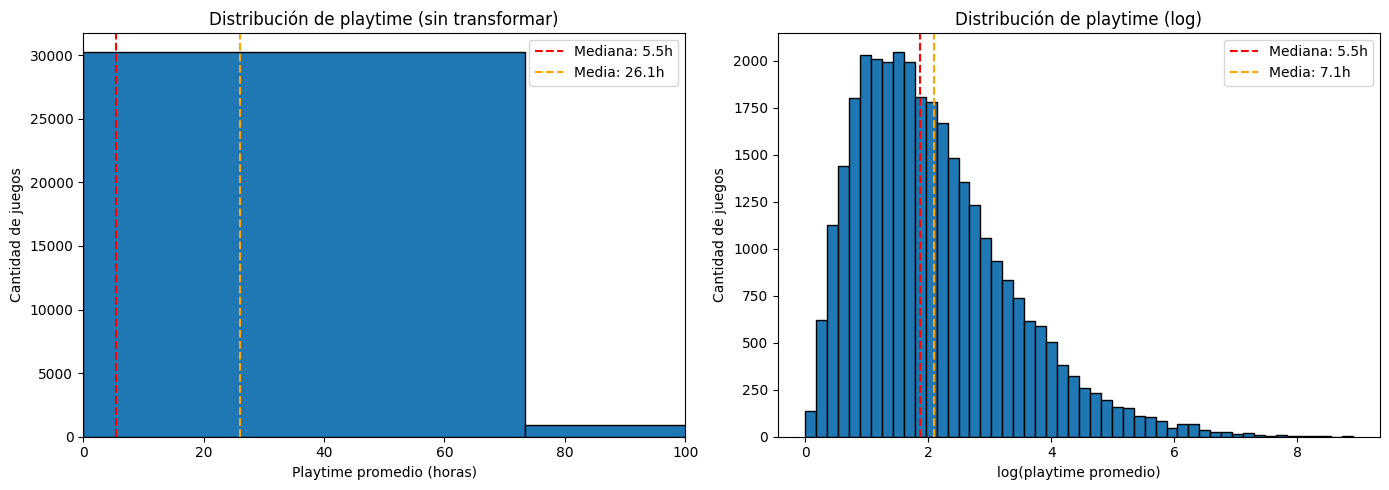

count    32147.000000
mean        26.053136
std        126.703676
min          0.000167
25%          2.136971
50%          5.463333
75%         15.171528
max       7340.052941
Name: playtime_mean, dtype: float64


In [5]:
# Filtrar juegos con al menos 5 reviews (promedio más confiable)
# Filtrar juegos con >= 5 reviews Y playtime > 0
playtime_filtrado = playtime_avg[
    (playtime_avg['n_reviews'] >= 5) & 
    (playtime_avg['playtime_mean'] > 0)
].copy()
print(f"Juegos filtrados: {len(playtime_filtrado):,}")

# Calcular estadísticas
media = playtime_filtrado['playtime_mean'].mean()
mediana = playtime_filtrado['playtime_mean'].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sin transformar
axes[0].hist(playtime_filtrado['playtime_mean'], bins=100, edgecolor='black')
axes[0].axvline(mediana, color='red', linestyle='--', label=f'Mediana: {mediana:.1f}h')
axes[0].axvline(media, color='orange', linestyle='--', label=f'Media: {media:.1f}h')
axes[0].set_xlim(0, 100)
axes[0].set_xlabel('Playtime promedio (horas)')
axes[0].set_ylabel('Cantidad de juegos')
axes[0].set_title('Distribución de playtime (sin transformar)')
axes[0].legend()

# Con log
# Con log
log_media = np.log1p(playtime_filtrado['playtime_mean']).mean()
log_mediana = np.log1p(playtime_filtrado['playtime_mean']).median()

# Invertir para mostrar en horas reales
media_real = np.expm1(log_media)
mediana_real = np.expm1(log_mediana)

axes[1].hist(np.log1p(playtime_filtrado['playtime_mean']), bins=50, edgecolor='black')
axes[1].axvline(log_mediana, color='red', linestyle='--', label=f'Mediana: {mediana_real:.1f}h')
axes[1].axvline(log_media, color='orange', linestyle='--', label=f'Media: {media_real:.1f}h')
axes[1].set_xlabel('log(playtime promedio)')
axes[1].set_ylabel('Cantidad de juegos')
axes[1].set_title('Distribución de playtime (log)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(playtime_filtrado['playtime_mean'].describe())

In [20]:
# === CELDA 3 COMPLETA: Merge + todas las features ===

# Cargar datos
df_apps = pd.read_csv('data-cleaned/applications.csv', low_memory=False)
df_application_genres = pd.read_csv('data/application_genres.csv')
df_application_platforms = pd.read_csv('data/application_platforms.csv')
df_genres = pd.read_csv('data-cleaned/genres_clean.csv')

# Merge playtime con applications
df_model = playtime_filtrado.merge(df_apps, on='appid', how='inner')
print(f"Juegos tras merge: {len(df_model):,}")

# --- Features originales ---
import re

def count_langs(x):
    if pd.isna(x): return 0
    clean = re.sub(r'<[^>]+>', '', str(x))
    clean = re.sub(r'\*', '', clean)
    return len([l for l in clean.split(',') if l.strip()])

df_model['n_languages'] = df_model['supported_languages'].apply(count_langs)
df_model['price_usd'] = df_model['mat_final_price'] / 100
df_model['release_date'] = pd.to_datetime(df_model['release_date'], errors='coerce')
df_model['release_year'] = df_model['release_date'].dt.year

n_genres = df_application_genres.groupby('appid').size().rename('n_genres')
n_platforms = df_application_platforms.groupby('appid').size().rename('n_platforms')
df_model = df_model.merge(n_genres, on='appid', how='left')
df_model = df_model.merge(n_platforms, on='appid', how='left')

# Target
df_model['log_playtime'] = np.log1p(df_model['playtime_mean'])

# Filtrar outliers de precio
df_model = df_model[df_model['price_usd'] <= 60].copy()

# --- Ronda 1: Features de applications ---
df_model['mat_discount_percent'] = df_model['mat_discount_percent'].fillna(0)
df_model['has_discount'] = (df_model['mat_discount_percent'] > 0).astype(int)
df_model['log_recs'] = np.log1p(df_model['recommendations_total'].fillna(0))

# --- Ronda 2: Features de reviews ---
review_stats = pd.read_csv('data/reviews.csv', 
    usecols=['appid', 'voted_up', 'steam_purchase', 'author_num_games_owned', 'votes_up'])

review_agg = review_stats.groupby('appid').agg(
    pct_positive=('voted_up', 'mean'),
    pct_steam_purchase=('steam_purchase', 'mean'),
    avg_games_owned=('author_num_games_owned', 'mean'),
    avg_votes_up=('votes_up', 'mean')
).reset_index()

df_model = df_model.merge(review_agg, on='appid', how='left')

# --- Ronda 3: Géneros one-hot (top 10) ---
app_gen = df_application_genres.merge(df_genres, left_on='genre_id', right_on='id')
app_gen = app_gen.rename(columns={'name': 'genre_name'})

top10 = app_gen['genre_name'].value_counts().head(10).index.tolist()
print("Top 10 géneros:", top10)

for genre in top10:
    col_name = f'genre_{genre.lower().replace(" ", "_")}'
    apps_with_genre = app_gen[app_gen['genre_name'] == genre]['appid'].unique()
    df_model[col_name] = df_model['appid'].isin(apps_with_genre).astype(int)

# --- Features finales ---
genre_cols = [c for c in df_model.columns if c.startswith('genre_')]

features_v2 = [
    # Originales
    'price_usd', 'mat_achievement_count', 'n_genres', 
    'n_platforms', 'n_languages', 'release_year',
    # Nuevas de applications
    'mat_discount_percent', 'has_discount', 'log_recs',
    # Nuevas de reviews
    'pct_positive', 'pct_steam_purchase', 'avg_games_owned', 'avg_votes_up',
] + genre_cols

print(f"\nTotal features: {len(features_v2)}")

modelo_df = df_model[features_v2 + ['log_playtime']].dropna()
print(f"Filas para modelar: {len(modelo_df):,}")
print(modelo_df.describe())

Juegos tras merge: 31,930
Top 10 géneros: ['Indie', 'Action', 'Casual', 'Adventure', 'Simulation', 'RPG', 'Strategy', 'Free To Play', 'Early Access', 'Sports']

Total features: 23
Filas para modelar: 18,930
          price_usd  mat_achievement_count      n_genres   n_platforms  \
count  18930.000000           18930.000000  18930.000000  18930.000000   
mean      10.502869              36.062018      2.852826      1.438352   
std       10.294776             154.308105      1.296133      0.733512   
min        0.490000               0.000000      1.000000      1.000000   
25%        2.990000              11.000000      2.000000      1.000000   
50%        6.990000              21.000000      3.000000      1.000000   
75%       14.990000              38.000000      4.000000      2.000000   
max       60.000000            5000.000000     10.000000      3.000000   

        n_languages  release_year  mat_discount_percent  has_discount  \
count  18930.000000  18930.000000          18930.0000

In [21]:
# === CELDA 4: Train/Test Split ===
X = modelo_df[features_v2]
y = modelo_df['log_playtime']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

# === CELDA 5-9: Entrenar los 4 modelos ===
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
y_pred_lr = modelo_lr.predict(X_test)

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
modelo_lr_poly = LinearRegression()
modelo_lr_poly.fit(X_train_poly, y_train)
y_pred_lr_poly = modelo_lr_poly.predict(X_test_poly)

modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

modelo_rf_poly = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf_poly.fit(X_train_poly, y_train)
y_pred_rf_poly = modelo_rf_poly.predict(X_test_poly)

# === CELDA 10: Tabla comparativa ===
y_pred_lr_train = modelo_lr.predict(X_train)
y_pred_lr_poly_train = modelo_lr_poly.predict(poly.transform(X_train))
y_pred_rf_train = modelo_rf.predict(X_train)
y_pred_rf_poly_train = modelo_rf_poly.predict(poly.transform(X_train))

def calcular_metricas(y_true, y_pred, y_true_train, y_pred_train):
    return {
        "R² train": r2_score(y_true_train, y_pred_train),
        "R² test": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

resumen = pd.DataFrame({
    "Reg. Lineal (Original)": calcular_metricas(y_test, y_pred_lr, y_train, y_pred_lr_train),
    "Reg. Lineal (Polinomial)": calcular_metricas(y_test, y_pred_lr_poly, y_train, y_pred_lr_poly_train),
    "Random Forest (Original)": calcular_metricas(y_test, y_pred_rf, y_train, y_pred_rf_train),
    "Random Forest (Polinomial)": calcular_metricas(y_test, y_pred_rf_poly, y_train, y_pred_rf_poly_train),
}).T

print(resumen)

# === Importancia de features ===
importancia = pd.Series(modelo_rf.feature_importances_, index=features_v2).sort_values(ascending=False)
print(f"\nTop 10 features más importantes:")
print(importancia.head(10))

X_train: (13251, 23)
X_test:  (5679, 23)
                            R² train   R² test      RMSE       MAE
Reg. Lineal (Original)      0.427251  0.442028  0.863647  0.651785
Reg. Lineal (Polinomial)    0.506952  0.440295  0.864987  0.617226
Random Forest (Original)    0.928854  0.509657  0.809617  0.599284
Random Forest (Polinomial)  0.928734  0.510048  0.809295  0.599489

Top 10 features más importantes:
log_recs                 0.310098
mat_achievement_count    0.126618
price_usd                0.108012
avg_games_owned          0.087263
avg_votes_up             0.071706
pct_positive             0.068962
release_year             0.042515
n_languages              0.037202
n_genres                 0.022552
genre_strategy           0.021289
dtype: float64


## Regresion

In [7]:
from sklearn.model_selection import train_test_split

X = modelo_df[features]
y = modelo_df['log_playtime']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (13251, 6)
X_test:  (5679, 6)


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
y_pred_lr = modelo_lr.predict(X_test)

print("=== Regresión Lineal ===")
print(f"R² test: {r2_score(y_test, y_pred_lr):.4f}")
print(f"\nCoeficientes:")
coefs = pd.DataFrame({'Feature': features, 'Coeficiente': modelo_lr.coef_})
print(coefs)
print(f"Intercepto: {modelo_lr.intercept_:.4f}")

=== Regresión Lineal ===
R² test: 0.2692

Coeficientes:
                 Feature  Coeficiente
0              price_usd     0.056024
1  mat_achievement_count     0.000406
2               n_genres     0.031847
3            n_platforms     0.126171
4            n_languages    -0.001224
5           release_year    -0.029921
Intercepto: 61.7957


In [9]:
residuos = y_test.values[:10] - y_pred_lr[:10]
df_residuos = pd.DataFrame({
    'y_real': np.round(y_test.values[:10], 3),
    'y_prediccion': np.round(y_pred_lr[:10], 3),
    'residuo': np.round(residuos, 3)
})
print(df_residuos)

   y_real  y_prediccion  residuo
0   1.393         2.504   -1.110
1   1.047         2.066   -1.020
2   2.050         2.138   -0.087
3   1.469         2.211   -0.742
4   2.337         2.235    0.102
5   2.478         2.578   -0.100
6   2.351         2.384   -0.033
7   1.543         2.155   -0.612
8   1.830         1.810    0.019
9   2.300         2.320   -0.020


In [10]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print(f"Features originales: {X_train.shape[1]}")
print(f"Features polinomiales: {X_train_poly.shape[1]}")

modelo_lr_poly = LinearRegression()
modelo_lr_poly.fit(X_train_poly, y_train)
y_pred_lr_poly = modelo_lr_poly.predict(X_test_poly)

Features originales: 6
Features polinomiales: 28


In [11]:
from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

In [12]:
modelo_rf_poly = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf_poly.fit(X_train_poly, y_train)
y_pred_rf_poly = modelo_rf_poly.predict(X_test_poly)

In [13]:
y_pred_lr_train = modelo_lr.predict(X_train)
y_pred_lr_poly_train = modelo_lr_poly.predict(poly.transform(X_train))
y_pred_rf_train = modelo_rf.predict(X_train)
y_pred_rf_poly_train = modelo_rf_poly.predict(poly.transform(X_train))

def calcular_metricas(y_true, y_pred, y_true_train, y_pred_train):
    return {
        "R² train": r2_score(y_true_train, y_pred_train),
        "R² test": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

resumen = pd.DataFrame({
    "Reg. Lineal (Original)": calcular_metricas(y_test, y_pred_lr, y_train, y_pred_lr_train),
    "Reg. Lineal (Polinomial)": calcular_metricas(y_test, y_pred_lr_poly, y_train, y_pred_lr_poly_train),
    "Random Forest (Original)": calcular_metricas(y_test, y_pred_rf, y_train, y_pred_rf_train),
    "Random Forest (Polinomial)": calcular_metricas(y_test, y_pred_rf_poly, y_train, y_pred_rf_poly_train),
}).T

print(resumen)

                            R² train   R² test      RMSE       MAE
Reg. Lineal (Original)      0.254221  0.269183  0.988404  0.758446
Reg. Lineal (Polinomial)    0.327671  0.326175  0.949082  0.711423
Random Forest (Original)    0.893716  0.309251  0.960926  0.724050
Random Forest (Polinomial)  0.896028  0.328232  0.947632  0.714258


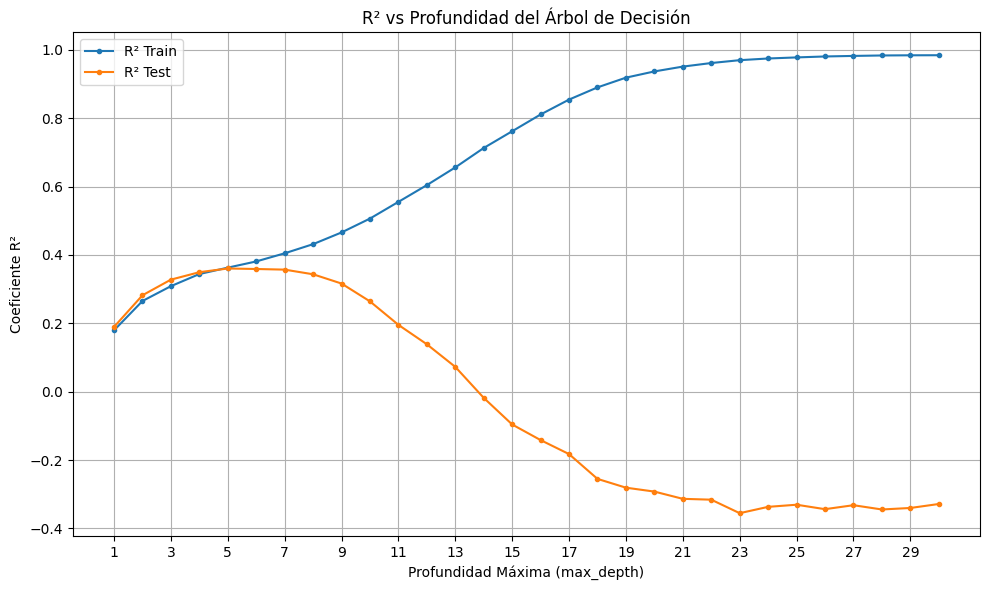

In [14]:
from sklearn.tree import DecisionTreeRegressor

res = []
for md in range(1, 31):
    tree = DecisionTreeRegressor(max_depth=md, random_state=42)
    tree.fit(X_train, y_train)
    res.append({
        'profundidad': md,
        'r2_train': tree.score(X_train, y_train),
        'r2_test': tree.score(X_test, y_test)
    })

df_depth = pd.DataFrame(res)

plt.figure(figsize=(10, 6))
plt.plot(df_depth['profundidad'], df_depth['r2_train'], label='R² Train', marker='o', markersize=3)
plt.plot(df_depth['profundidad'], df_depth['r2_test'], label='R² Test', marker='o', markersize=3)
plt.title('R² vs Profundidad del Árbol de Decisión')
plt.xlabel('Profundidad Máxima (max_depth)')
plt.ylabel('Coeficiente R²')
plt.xticks(range(1, 31, 2))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

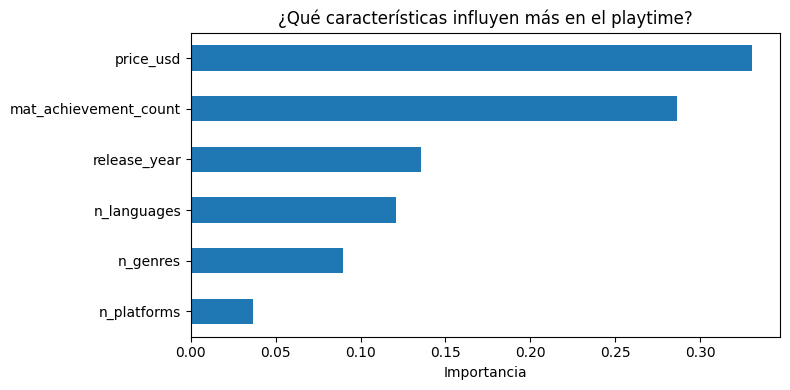

In [15]:
importancia = pd.Series(modelo_rf.feature_importances_, index=features).sort_values()

plt.figure(figsize=(8, 4))
importancia.plot.barh()
plt.xlabel('Importancia')
plt.title('¿Qué características influyen más en el playtime?')
plt.tight_layout()
plt.show()

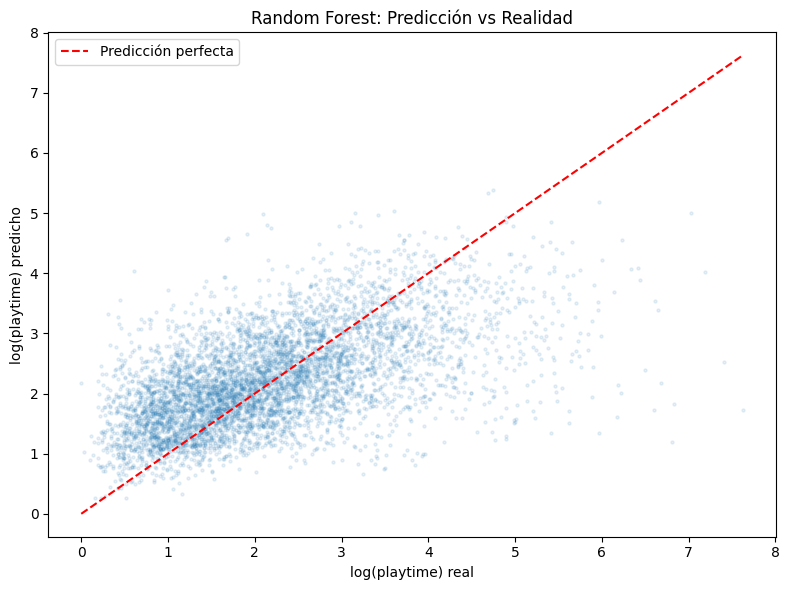

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.1, s=5)
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Predicción perfecta')
plt.xlabel('log(playtime) real')
plt.ylabel('log(playtime) predicho')
plt.title('Random Forest: Predicción vs Realidad')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
print("Features:", features)
print("Target: log_playtime")
print(f"Shape: {X_train.shape[1]} columnas")

Features: ['price_usd', 'mat_achievement_count', 'n_genres', 'n_platforms', 'n_languages', 'release_year']
Target: log_playtime
Shape: 6 columnas


In [18]:
print("Columnas disponibles en df_apps:")
print(df_apps.columns.tolist())
print(f"\nShape: {df_apps.shape}")

Columnas disponibles en df_apps:
['appid', 'name', 'type', 'is_free', 'release_date', 'short_description', 'supported_languages', 'metacritic_score', 'recommendations_total', 'mat_supports_windows', 'mat_supports_mac', 'mat_supports_linux', 'mat_initial_price', 'mat_final_price', 'mat_discount_percent', 'mat_currency', 'mat_achievement_count', 'mat_pc_os_min', 'mat_pc_processor_min', 'mat_pc_memory_min', 'mat_pc_graphics_min', 'mat_pc_os_rec', 'mat_pc_processor_rec', 'mat_pc_memory_rec', 'mat_pc_graphics_rec', 'created_at', 'updated_at']

Shape: (204071, 27)


In [19]:
# Ver qué columnas numéricas tienen datos útiles
print(df_apps.describe())

              appid  metacritic_score  recommendations_total  \
count  2.040710e+05       4426.000000           2.241500e+04   
mean   1.991415e+06         74.017849           4.675253e+03   
std    1.055149e+06         10.277721           4.657130e+04   
min    1.000000e+01          6.000000           1.010000e+02   
25%    1.097985e+06         68.000000           1.750000e+02   
50%    1.937360e+06         76.000000           3.710000e+02   
75%    2.878555e+06         81.000000           1.216000e+03   
max    3.990870e+06         97.000000           4.661011e+06   

       mat_initial_price  mat_final_price  mat_discount_percent  \
count       1.372520e+05     1.372520e+05         137252.000000   
mean        2.336376e+04     2.125079e+04              5.354334   
std         8.772064e+05     7.971281e+05             17.843623   
min         5.000000e+01     4.400000e+01              0.000000   
25%         2.990000e+02     2.990000e+02              0.000000   
50%         4.990000e